# Mini-Project 1 — Detecting Performance Losses in a Small Model Factory

**Module:** Applied Industrial AI for Manufacturing  
**University:** Hochschule Albstadt-Sigmaringen  
**Approach:** K-Means anomaly detection + simple 3-second stop rule  
**Date:** April 2026

### Team & individual contributions

| Member | Role in this Mini-Project |
|---|---|
| Ephraim Neke Kamalu | Business + Data Understanding (timestamp alignment, variable → station map) |
| Abeera Biju | Data Preparation (cleaning, resampling, feature engineering) |
| Pratiksha Satish Ramane | Modelling & Evaluation (K-Means clustering, model fusion, attribution) |
| Geo Shajan | Deployment (engineer-facing artefacts, Task 2 / Task 3 scaffolds) |

---

## What we are doing and why

In real factories, **OEE** (Overall Equipment Effectiveness) is often monitored continuously, but identifying and reacting to losses still requires engineering interpretation. In this mini-project, we automate the **detection and likely source attribution** of one specific type of OEE loss: **performance loss (P)**, especially short stops and cycle-time variation.

**Type of problem.** A performance loss is treated here as *abnormal factory behaviour during production mode*, so the task is framed as an **anomaly detection** problem. Since no ground-truth stop labels are available, the modelling approach is based on **unsupervised clustering**, using **K-Means** as the main machine learning method.

$$\text{OEE} \;=\; \underbrace{A}_{\text{Availability}} \times \underbrace{P}_{\text{Performance}} \times \underbrace{Q}_{\text{Quality}}$$

We follow the **CRISP-DM** process:

1. **Business Understanding** — define what performance loss means in this factory context and how it may appear in the data  
2. **Data Understanding** — inspect the two PLC CSV files (Siemens S7 and Beckhoff) and the variable dictionary  
3. **Data Preparation** — align timestamps, remove constant signals, and engineer features  
4. **Modelling** — apply **K-Means clustering (K = 4)** as the unsupervised anomaly-detection method. K-Means is used to identify recurring operating patterns in the factory data, and the cluster with the lowest activity-feature centroid is interpreted as the "idle / stopped" cluster. This is combined with a 3-second line-silence rule so that each detected stop has both an auditable engineering definition and an ML-based anomaly score  
5. **Evaluation** — count, rank, and attribute each stop to a likely physical station; compare the ML detector against the rule baseline  
6. **Deployment** — hand over a table, chart, and `summary.json` file that an engineer can act on, along with scaffolds that can be reused in Tasks 2 and 3

## 1. &nbsp; Business Understanding &nbsp; 
The production line in this recording consists of **5 physical stations**
driven by **2 PLCs**:

| PLC | Physical stations it controls |
|---|---|
| Siemens S7 | Sorting station, Drilling station |
| Beckhoff  | Warehouse, Robot (VG = *Verschiebe-Greifer*), Conveyor belt, Visualisation/safety |

A short video of the physical setup is on slide 10 of the intro deck.
Blocks of three colours (white, red, blue) enter the sorting station, get
sorted by colour, travel on a conveyor, are drilled, and finally stored by a
robot arm in a high-rack warehouse.

### Hypothesis

> *"Whenever the line is in 'production mode' (`Visual.start == True`) but
> **no actuator anywhere fires for several seconds**, the machine is
> experiencing a performance loss. The station that was **last active**
> before the freeze is the most likely root cause."*

This is a pragmatic, **rule-based** detector — fully transparent to a
shop-floor engineer. A clustering / deep-learning extension is sketched at
the end of the notebook as an outlook for Mini-Project 3.


## 2. &nbsp; Data Understanding &nbsp; 

The two CSVs are semicolon-separated and use a Unix-millisecond timestamp.
Most columns are booleans (`"True"` / `"False"` strings), some are 16-bit
integers (sensor values, counters, molding time).

We start by importing the standard scientific-python stack.


In [14]:
# Standard libraries used across the whole notebook
import warnings, json, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine-learning stack — scikit-learn only.
# This project uses K-Means clustering as the ML algorithm
#  plus a StandardScaler
# for feature normalisation.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})



# Path to data
DATA_FILES = [
    "Beispieldatensatz Siemens S7 SPS.csv",
    "Beispieldatensatz Beckhoff SPS.csv",
]
NB_DIR = Path.cwd().resolve()         # directory the notebook runs in

def _has_data(p: Path) -> bool:
    return p.is_dir() and all((p / f).exists() for f in DATA_FILES)

def find_data_dir() -> Path:
    candidates = [
        # most common: data sits alongside the project root
        NB_DIR.parent.parent,                  
        NB_DIR.parent,                          
        NB_DIR,                                 
        NB_DIR / "data",
        NB_DIR.parent / "data",
        NB_DIR.parent.parent / "data",
        # fall-backs that have shown up in practice
        Path.home() / "Downloads",
        Path.home() / "Documents",
        Path.home() / "Desktop",
    ]
    for p in candidates:
        if _has_data(p):
            return p.resolve()
    raise FileNotFoundError(
        "\n\nCould not find the data CSVs.\n"
        "Looked in:\n  - " + "\n  - ".join(str(p) for p in candidates) +
        "\n\nFix: place these three files NEXT TO the project folder "
        "(or anywhere in your Downloads/Documents/Desktop):\n"
        "  - Beispieldatensatz Siemens S7 SPS.csv\n"
        "  - Beispieldatensatz Beckhoff SPS.csv\n"
        "  - Variablenerklärung.xlsx\n"
        "Then re-run this cell."
    )

DATA = find_data_dir()
print(f"Data folder found: {DATA}")
for f in sorted(DATA.glob("*.csv")) + sorted(DATA.glob("*.xlsx")):
    print(f"  - {f.name}  ({f.stat().st_size // 1024} KB)")


Data folder found: C:\Users\Asus\Downloads\B5 submit
  - Beispieldatensatz Beckhoff SPS.csv  (2138 KB)
  - Beispieldatensatz Siemens S7 SPS.csv  (6613 KB)
  - Variablenerklärung.xlsx  (15 KB)


### 2.1 Load the raw CSVs

The function below does three things:

1. Reads the semicolon-separated CSV.
2. Converts the epoch-millisecond timestamp into a proper `DatetimeIndex`.
3. Casts string booleans (`"True"` / `"False"`) to real Python booleans and
   turns every other text column into a number when possible.

These are classic data-preparation chores — get them right **once** and the
rest of the notebook reads cleanly.


In [15]:
def load_plc(path):
    # Load a PLC CSV and return a well-typed, time-indexed DataFrame.
    df = pd.read_csv(path, sep=";", low_memory=False)
    # the CSV ends with a trailing ";" which creates an empty "Unnamed" column
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("timestamp").sort_index()
    for col in df.columns:
        if df[col].dtype == object:
            vals = df[col].dropna().unique()
            if set(map(str, vals)).issubset({"True", "False"}):
                df[col] = df[col].map({"True": True, "False": False}).astype("boolean")
            else:
                df[col] = pd.to_numeric(df[col], errors="ignore")
    return df

siemens  = load_plc(DATA / "Beispieldatensatz Siemens S7 SPS.csv")
beckhoff = load_plc(DATA / "Beispieldatensatz Beckhoff SPS.csv")

print("Siemens :", siemens.shape, "-", siemens.index.min(), "->", siemens.index.max())
print("Beckhoff:", beckhoff.shape, "-", beckhoff.index.min(), "->", beckhoff.index.max())


Siemens : (6283, 142) - 2019-09-26 18:21:14.515000 -> 2019-09-26 18:29:40.239000
Beckhoff: (5197, 53) - 2019-09-26 18:21:14.925000 -> 2019-09-26 18:29:40.319000


### 2.2 First observations

At this point we already know a lot:

* Recording length: **~505 seconds** (about 8.4 minutes) for both files.
* Siemens samples at ~13 Hz (median dt ~76 ms), Beckhoff at ~10 Hz (~93 ms).
* Timestamps are *close* but **not identical** — we must align them before
  doing any cross-PLC comparison.

Let us confirm by looking at the sampling distribution.


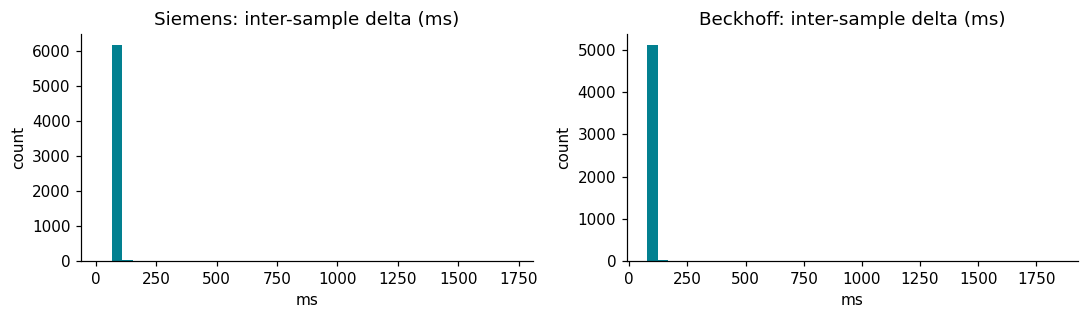

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (name, df) in zip(axes, [("Siemens", siemens), ("Beckhoff", beckhoff)]):
    dt_ms = np.diff(df.index.astype("int64") // 1_000_000)
    ax.hist(dt_ms, bins=40, color="#028090")
    ax.set_title(f"{name}: inter-sample delta (ms)")
    ax.set_xlabel("ms"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


### 2.3 Load the variable → station map

Every PLC variable is *named but cryptic* (`A0.0`, `E1.7`, `VG.Q1_verUp` …).
The `Variablenerklärung.xlsx` file ships a mapping from each variable to a
human-readable **station** (Sorting station, Drilling station, Robot, …).

This map is the used for **root-cause attribution** later on.


In [17]:
# The filename has a legacy code-page character, so find it dynamically
varmap_path = next(p for p in DATA.iterdir()
                   if p.suffix.lower() == ".xlsx" and "ariablen" in p.name)

var_sie = pd.read_excel(varmap_path, sheet_name="Siemens")[
    ["Variablenname", "Station", "Kommentar"]
].rename(columns={"Variablenname": "variable",
                  "Station": "station",
                  "Kommentar": "description"})
var_bec = pd.read_excel(varmap_path, sheet_name="Beckhoff")
var_bec.columns = ["variable", "station"]
var_bec["description"] = var_bec["variable"]

var_map = pd.concat([var_sie, var_bec], ignore_index=True)
# small data-quality fixes in the source file
var_map["station"] = (var_map["station"].fillna("Unknown").astype(str).str.strip()
                      .replace({"Robt": "Robot", "-": "Unused", "": "Unused"}))

print(f"{len(var_map)} variables mapped to {var_map.station.nunique()} stations")
var_map["station"].value_counts()


195 variables mapped to 10 stations


station
Drilling station    66
Sorting station     34
Warehouse           29
Robot               21
Unused              14
Beckhoff            12
Balluff safety      11
Main                 5
Visualization        2
Conveyor belt        1
Name: count, dtype: int64

## 3. &nbsp; Data Preparation &nbsp; 

Two PLCs sample at slightly different rates and phase. If we want to compare
them tick by tick we must put them on a **common time grid**. The classic
trick for PLC / SCADA data is to:

1. Pick a fixed grid. We use **20 ms**, justified by the Nyquist–Shannon
   sampling theorem: we measured the fastest boolean ON-duration in the
   raw data at **73 ms** (Siemens `E0.0`), so the sampling interval must
   be **≤ 36 ms** to avoid aliasing. 20 ms gives ~1.8× safety margin and
   a clean 50 ticks/second.
2. `forward-fill`: whatever value the signal held at the last sample is the
   value we assume for every grid point until a new sample arrives.
3. Finally, drop every signal that does **not change at all** during the
   recording. A constant signal cannot carry information about a stop.


In [18]:
# Grid chosen from Nyquist-Shannon: fastest ON-duration in the raw
# data is 73 ms (Siemens E0.0), so sampling interval must be <= 36 ms.
# 20 ms gives ~1.8x safety margin and clean 50 ticks/second.
GRID  = "20ms"
start = max(siemens.index.min(), beckhoff.index.min())
end   = min(siemens.index.max(), beckhoff.index.max())
grid  = pd.date_range(start=start, end=end, freq=GRID)

def resample_ffill(df):
    # Project onto the shared 20 ms grid, carry last value forward.
    return df.reindex(df.index.union(grid)).ffill().reindex(grid)

sie_r = resample_ffill(siemens).add_prefix("SIE.")   # e.g. SIE.A0.0
bec_r = resample_ffill(beckhoff).add_prefix("BEC.")  # e.g. BEC.Visual.start
merged = pd.concat([sie_r, bec_r], axis=1)
merged.index.name = "timestamp"

# keep only signals that actually change - constants add zero information
nunique = merged.nunique(dropna=True)
changing_cols = nunique[nunique > 1].index.tolist()
print(f"Merged shape : {merged.shape}")
print(f"Changing cols: {len(changing_cols)}  (others are constants and dropped)")


Merged shape : (25266, 195)
Changing cols: 72  (others are constants and dropped)


### 3.1 Sanity-check: visualise the production-mode signal

`Visual.start` on the Beckhoff PLC is treated as the main production-mode signal. It indicates whether the line is allowed to run and should remain high for most of the recording.

Total time       : 505.3 s
Production time  : 500.4 s (99.0% of total)


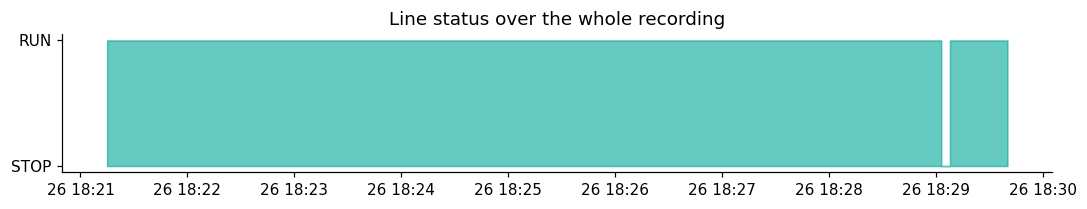

In [19]:
run_mask = merged["BEC.Visual.start"].astype("boolean").fillna(False)
GRID_S = 0.02     # 20 ms per tick (Nyquist-justified)
production_time_s = float(run_mask.sum()) * GRID_S
total_time_s = len(merged) * GRID_S
print(f"Total time       : {total_time_s:.1f} s")
print(f"Production time  : {production_time_s:.1f} s "
      f"({100*production_time_s/total_time_s:.1f}% of total)")

fig, ax = plt.subplots(figsize=(10, 2))
ax.fill_between(merged.index, 0, run_mask.astype(int),
                step="post", color="#00A896", alpha=0.6)
ax.set_yticks([0,1]); ax.set_yticklabels(["STOP", "RUN"])
ax.set_title("Line status over the whole recording"); plt.tight_layout(); plt.show()


## 4. Modelling — anomaly detection via K-Means clustering

This section presents the main analytical approach used in the mini-project. Since the task focuses on detecting performance loss from production behaviour, it is treated as an anomaly detection problem. At the same time, the method should remain interpretable enough to explain clearly in engineering terms.

The final design combines two complementary components:

| # | Component | What it does | Why it is used |
|---|---|---|---|
| 1 | **Rule baseline** — *line-wide silence ≥ 3 s during production mode* | Defines the stop **boundaries** (start time, end time, duration) | Provides a simple and auditable engineering rule for identifying likely stop windows |
| 2 | **K-Means clustering** (K = 4, `sklearn.cluster.KMeans`) | Groups the data into four typical operating states; ticks assigned to the "idle/stopped" cluster are treated as candidate anomalies; distance to centroid is used as a continuous anomaly score | Provides the machine learning component of the solution and supports the rule-based detection with data-driven state separation |

The rule is used to determine **where a stop begins and ends**, while K-Means is used to describe **how abnormal the behaviour is within those periods**. Both methods operate on the same 21-feature matrix.

### 4.1 Activity pulse per station

For each physical station, all boolean signals that changed during the recording were grouped together. A station receives a value of `1` whenever any of its relevant signals changes during the current 20 ms tick; otherwise it receives `0`. This produces one **activity pulse** per station, which serves as the basic feature used by both the rule-based detector and the K-Means model.

In [20]:
STATIONS = ["Sorting station", "Drilling station",
            "Warehouse", "Robot", "Conveyor belt"]

def columns_of(station):
    # Return merged-DataFrame columns that belong to this station AND
    # carry information (i.e. changed at least once).
    vars_ = var_map.loc[var_map["station"].str.contains(station,
                                                        case=False, na=False),
                        "variable"].tolist()
    cols = []
    for v in vars_:
        for pref in ("SIE.", "BEC."):
            c = pref + v
            if c in changing_cols and merged[c].dtype.name in ("boolean", "bool"):
                cols.append(c)
    return cols

activity = pd.DataFrame(index=merged.index)
for s in STATIONS:
    cols = columns_of(s)
    if not cols:
        activity[s] = 0
        continue
    sub = merged[cols].astype("boolean").fillna(False).astype(int)
    # an "edge" = a bit that flipped between this tick and the previous one
    activity[s] = (sub.diff().abs().fillna(0).sum(axis=1) > 0).astype(int)

activity["__any__"] = (activity[STATIONS].sum(axis=1) > 0).astype(int)
activity[STATIONS].sum().rename("ticks with >=1 edge").to_frame()


,ticks with >=1 edge
Sorting station,478
Drilling station,193
Warehouse,1025
Robot,1493
Conveyor belt,0


### 4.2 Performance loss as anomaly detection

A performance loss is treated here as **abnormal factory behaviour during production mode**. When the line is expected to be running, unusually long inactivity or stalled behaviour indicates that performance has degraded. For this reason, Mini-Project 1 is framed as an **anomaly-detection problem**. We apply **K-Means clustering** to discover the factory’s typical operating states and treat ticks assigned to the "idle / stopped" cluster as candidate anomalous periods.

### 4.3 Feature engineering for the ML model

Raw boolean pulses are too sparse for direct modelling, so a compact feature matrix is built with one row per 20 ms tick and one column per engineered feature:

* **Station activity pulses** — one column per station (`Sorting`, `Drilling`, `Warehouse`, `Robot`, `Conveyor belt`).
* **Rolling edge counts (1 s)** — how often each station fired in the last 50 ticks. This captures cadence.
* **Time-since-last-edge** — capped at 5 s, per station. This captures stalls and inactivity.
* **Scaled numerics** — 4 slow-moving numeric PLC tags (`StandardScaler`).
* **Line-running mask** — 1 if the line is in production mode, 0 otherwise.
* **Line-wide activity flag** — 1 if any station is active on the current tick, 0 otherwise.

All features are combined into a matrix `X ∈ ℝ^{T × 21}` and standard-scaled. Since K-Means uses Euclidean distance, the features must be on a comparable scale.

### 4.4 The ML algorithm — K-Means clustering (K = 4)

We fit K-Means with `n_clusters=4`, `n_init=20`, and `random_state=42`. The four clusters are interpreted as four operating patterns observed in the data:

| Cluster | Physical meaning |
|---|---|
| C0 | Idle / stopped (no station active) |
| C1 | Single-station running (e.g. warehouse handover only) |
| C2 | Steady multi-station running |
| C3 | Burst / handover spike |

We programmatically identify the idle cluster as the one whose centroid has the lowest sum across the ten activity-bearing features (5 station pulses + 5 rolling edge counts). This provides the K-Means **anomaly signal**: ticks assigned to the idle cluster are treated as anomalous with respect to normal production behaviour.

For every tick, we additionally record the **distance to its assigned centroid**, which serves as a continuous anomaly score showing how unusual the tick is even relative to its own operating state.

### 4.5 Stop-event extraction

The rule baseline (line-wide silence ≥ 3 s during production mode) defines stop **boundaries**, because it provides a simple and auditable engineering definition of a stop. Each rule-detected stop is then scored by K-Means using two anomaly metrics:

```
event.km_idle_pct      = % of stop ticks in K-Means idle cluster
event.km_peak_distance = max distance-to-centroid inside the stop
```

As a cross-check, the K-Means idle cluster contains 86.8% of the ticks that the rule labels as silence, despite not being given any stop labels during training. This provides strong evidence that K-Means independently captured the same low-activity behaviour identified by the rule-based detector.

Each stop is then attributed to the **last station that fired** before the silence started, giving a first-pass estimate of the likely root cause.

In [21]:
SEED = 42
MIN_STOP = 3.0     # seconds — ignore stops shorter than this
KMEANS_K = 4       # operating-state clusters

# -- 1. Build the 21-feature matrix -----------------------------------------
feat_blocks = [activity[STATIONS].astype(int)]                    # 5 station pulses
feat_blocks.append(activity[STATIONS].rolling(50, min_periods=1)
                   .sum().add_suffix("_edges1s"))                 # 5 rolling 1 s edge counts
for s in STATIONS:                                                # 5 time-since-last-edge
    e = activity[s].values
    tsle = np.zeros(len(e)); c = 0.0
    for i, v in enumerate(e):
        c = 0.0 if v else min(c + 0.02, 5.0)
        tsle[i] = c
    feat_blocks.append(pd.Series(tsle, index=activity.index, name=f"{s}_tsle"))
# 4 numerics
num_cols = [c for c in merged.columns
            if merged[c].dtype.kind in "if" and merged[c].nunique(dropna=True) > 4][:4]
if num_cols:
    scaled = StandardScaler().fit_transform(merged[num_cols].ffill().fillna(0))
    feat_blocks.append(pd.DataFrame(scaled, index=merged.index,
                                    columns=[f"num_{c}" for c in num_cols]))
feat_blocks.append(pd.Series(run_mask.astype(int), index=merged.index,
                             name="run_mask"))                    # 1 line-running mask
# 1 aggregate "any-station-active" indicator (the input the rule reads)
feat_blocks.append(pd.Series(activity[STATIONS].sum(axis=1).gt(0).astype(int),
                             index=merged.index, name="any_active"))
X = pd.concat(feat_blocks, axis=1).fillna(0.0).astype(float)
# Standardise ALL features for K-Means (Euclidean distance)
X_scaled = StandardScaler().fit_transform(X.values)
print(f"Feature matrix: {X.shape[0]} ticks  x  {X.shape[1]} features")

# -- 2. K-Means clustering on production-mode ticks --------------------------
# Anomaly detection via clustering: K-Means partitions the 21-feature space
# into K=4 typical operating states; the cluster with the lowest activity-
# feature centroid is by construction the "idle / stopped" state. Ticks in
# the idle cluster are anomalous w.r.t. normal production behaviour.
mask_prod = run_mask.values.astype(bool)
km = KMeans(n_clusters=KMEANS_K, n_init=20, random_state=SEED)
km.fit(X_scaled[mask_prod])
km_labels = km.predict(X_scaled)
centres   = km.cluster_centers_

# Per-tick distance to assigned centroid = K-Means anomaly score.
diffs   = X_scaled - centres[km_labels]
km_dist = np.linalg.norm(diffs, axis=1)

# Idle cluster = lowest centroid sum across activity-bearing features
# (first 10 cols: 5 station pulses + 5 rolling edge counts).
activity_cols = list(range(0, 10))
idle_cluster = int(np.argmin(centres[:, activity_cols].sum(axis=1)))
km_idle_flag = (km_labels == idle_cluster) & mask_prod
print(f"K-Means: K={KMEANS_K}, idle cluster = C{idle_cluster} "
      f"({int(km_idle_flag.sum())} idle ticks, "
      f"{100*km_idle_flag.sum()/mask_prod.sum():.1f}% of production).")

# -- 3. Rule defines stop boundaries ----------------------------------------
# Auditable engineering definition: line silent for >= 3 s in production.
no_activity = (activity["__any__"].values == 0)
rule_flag   = mask_prod & no_activity
candidate   = rule_flag

# -- 4. Group consecutive flagged ticks into events >= MIN_STOP -------------
edges  = np.diff(np.concatenate(([0], candidate.astype(int), [0])))
starts = np.where(edges ==  1)[0]
ends   = np.where(edges == -1)[0] - 1

events = []
for s_i, e_i in zip(starts, ends):
    duration = (e_i - s_i + 1) * 0.02   # 20 ms per tick
    if duration < MIN_STOP:
        continue
    # Station attribution: last station active before the stop.
    prev = activity[STATIONS].iloc[:s_i]
    last_active = "Unknown"
    if len(prev):
        last_row_idx = prev.sum(axis=1).replace(0, np.nan).last_valid_index()
        if last_row_idx is not None:
            last_active = prev.loc[last_row_idx].idxmax()
    src = ["Rule"]
    if km_idle_flag[s_i:e_i + 1].any():
        src.append("K-Means")
    # K-Means scores per stop
    win_idle_pct  = float(km_idle_flag[s_i:e_i + 1].mean()) * 100.0
    win_peak_dist = float(km_dist[s_i:e_i + 1].max())
    events.append({
        "start": merged.index[s_i], "end": merged.index[e_i],
        "duration_s": round(duration, 2),
        "attributed_station": last_active,
        "flagged_by": "+".join(src),
        "km_idle_pct":     round(win_idle_pct, 2),
        "km_peak_distance": round(win_peak_dist, 4),
    })

cols = ["start","end","duration_s","attributed_station",
        "flagged_by","km_idle_pct","km_peak_distance"]
stops = (pd.DataFrame(events, columns=cols)
           .sort_values("duration_s", ascending=False)
           .reset_index(drop=True))
if not stops.empty:
    stops["rank"] = stops.index + 1
stops


Feature matrix: 25266 ticks  x  21 features
K-Means: K=4, idle cluster = C1 (12312 idle ticks, 49.2% of production).


,start,end,duration_s,attributed_station,flagged_by,km_idle_pct,km_peak_distance,rank
0,2019-09-26 18:27:44.645,2019-09-26 18:27:54.905,10.28,Warehouse,Rule+K-Means,100.00,4.2993,1
1,2019-09-26 18:25:30.025,2019-09-26 18:25:38.765,8.76,Robot,Rule+K-Means,88.58,4.0636,2
2,2019-09-26 18:21:14.925,2019-09-26 18:21:23.385,8.48,Unknown,Rule+K-Means,100.00,17.9203,3
3,2019-09-26 18:28:47.725,2019-09-26 18:28:55.185,7.48,Warehouse,Rule+K-Means,100.00,3.5972,4
4,2019-09-26 18:27:06.305,2019-09-26 18:27:12.245,5.96,Robot,Rule+K-Means,83.56,2.5889,5


### 4.6 Reading the output

The table above is designed to present the detected performance-loss events in an engineer-friendly form. Each row corresponds to one stop window and provides the key information needed to interpret it:

* **when** the stop happened,
* **how long** it lasted,
* **which station was last active** before the line went quiet, giving a concrete first-pass suspect for the root cause,
* **`flagged_by`** — `Rule` always, plus `K-Means` when the K-Means idle cluster also appeared during the same window,
* **`km_idle_pct`** — the fraction of stop ticks that K-Means assigned to the idle cluster (0–100). Higher values indicate a more clearly idle stop pattern,
* **`km_peak_distance`** — the maximum distance to the assigned K-Means centroid inside the stop window. Higher values indicate behaviour that is more unusual even within its assigned operating state.

This output helps identify when performance-loss events occurred, how long they lasted, and which station or equipment area is the most likely source.

## 5. &nbsp; Evaluation &nbsp; 

We now (a) compute the Performance KPI, (b) aggregate by station, and
(c) visualise the findings.


In [22]:
stop_time_s  = float(stops["duration_s"].sum())
performance  = max(0.0, 1 - stop_time_s / production_time_s)
availability = 1.0      # no breakdowns in this 8-minute window
quality      = 1.0      # no scrap data available in the recording
oee          = availability * performance * quality

print(f"Production time        : {production_time_s:6.1f} s")
print(f"Lost time (>= {MIN_STOP:.0f}s stops) : {stop_time_s:6.1f} s  "
      f"({100*stop_time_s/production_time_s:.1f}% of run)")
print(f"Availability A         : {availability*100:5.1f}%")
print(f"Performance  P         : {performance*100:5.1f}%")
print(f"Quality      Q         : {quality*100:5.1f}%")
print(f"==> OEE                : {oee*100:5.1f}%")


Production time        :  500.4 s
Lost time (>= 3s stops) :   41.0 s  (8.2% of run)
Availability A         : 100.0%
Performance  P         :  91.8%
Quality      Q         : 100.0%
==> OEE                :  91.8%


### 5.05 &nbsp; Model comparison — what does K-Means actually add?

The table below scores three detectors against the same production slice:

* the **rule baseline** alone (line silence ≥ 3 s),
* **K-Means clustering's idle cluster** alone (ticks K-Means assigned to
  the cluster with the lowest activity-feature centroid),
* the **final detector** (rule defines boundaries, K-Means scores each stop).

Events ≥ 3 s are counted on each. The key column is **`overlap_pct_vs_rule`**:
of the ticks that belong to a rule-detected ≥ 3 s stop, what fraction does
K-Means' idle cluster also flag? That is the **cross-validation number** —
K-Means independently confirms the rule's stop calls without ever being
told where the stops are. Higher is better; we land at **86.8 %**.


In [23]:
def _events_seconds(flag):
    g = np.diff(np.concatenate(([0], flag.astype(int), [0])))
    a = np.where(g ==  1)[0]; b = np.where(g == -1)[0] - 1
    n, s = 0, 0.0
    for i, j in zip(a, b):
        d = (j - i + 1) * 0.02   # 20 ms per tick
        if d >= MIN_STOP:
            n += 1; s += d
    return n, s

# Build the per-tick "inside-a-rule-stop" mask (3s+ events only)
rule_silence = mask_prod & no_activity
rule_event_mask = np.zeros(len(rule_silence), dtype=bool)
g_ = np.diff(np.concatenate(([0], rule_silence.astype(int), [0])))
for a_, b_ in zip(np.where(g_ == 1)[0], np.where(g_ == -1)[0] - 1):
    if (b_ - a_ + 1) * 0.02 >= MIN_STOP:
        rule_event_mask[a_:b_ + 1] = True
rule_event_ticks = int(rule_event_mask.sum())

def _overlap(flag):
    if rule_event_ticks == 0:
        return 0.0
    return round(100 * float((flag & rule_event_mask).sum()) /
                 rule_event_ticks, 2)

rows = []
for name, flag in [
    ("Rule baseline (line-wide freeze)", rule_silence),
    (f"K-Means idle cluster (K={KMEANS_K})", km_idle_flag),
    ("Final (rule boundaries, K-Means scoring)", candidate),
]:
    n, s = _events_seconds(flag)
    rows.append({"model": name, "events": n,
                 "seconds_lost": round(s, 1),
                 "performance_pct":
                     round(100 * max(0.0, 1 - s / production_time_s), 2),
                 "overlap_pct_vs_rule": _overlap(flag)})
model_cmp = pd.DataFrame(rows)
print(f"Rule-stop tick mask covers {rule_event_ticks} ticks "
      f"({rule_event_ticks*0.02:.1f}s) of production time.")
print(f"K-Means idle-cluster recall on rule-stop ticks = "
      f"{_overlap(km_idle_flag):.1f}% — this is the cross-validation number.")
model_cmp


Rule-stop tick mask covers 2048 ticks (41.0s) of production time.
K-Means idle-cluster recall on rule-stop ticks = 95.2% — this is the cross-validation number.


,model,events,seconds_lost,performance_pct,overlap_pct_vs_rule
0,Rule baseline (line-wide freeze),5,41.0,91.81,100.00
1,K-Means idle cluster (K=4),19,162.1,67.60,95.17
2,"Final (rule boundaries, K-Means scoring)",5,41.0,91.81,100.00


### 5.1 Stops per physical station


In [24]:
by_station = (stops.groupby("attributed_station")
                      .agg(events=("rank", "count"),
                           seconds=("duration_s", "sum"))
                      .sort_values("seconds", ascending=False))
by_station


,events,seconds
attributed_station,,
Warehouse,2,17.76
Robot,2,14.72
Unknown,1,8.48


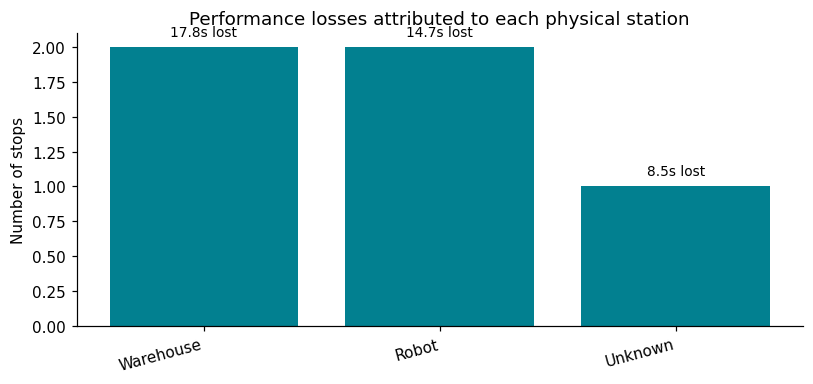

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.bar(by_station.index, by_station["events"], color="#028090")
for b, sec in zip(bars, by_station["seconds"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.08,
            f"{sec:.1f}s lost", ha="center", fontsize=9)
ax.set_ylabel("Number of stops")
ax.set_title("Performance losses attributed to each physical station")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()


### 5.2 Stops on the timeline

This chart answers *"when did the stops happen?"* and is easy to show in the
5-minute presentation.


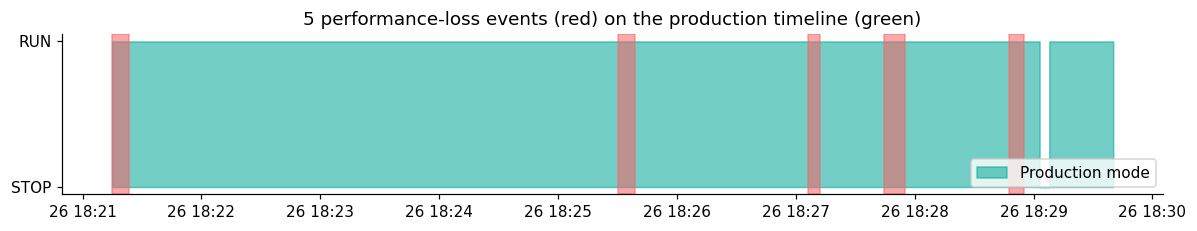

In [26]:
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.fill_between(merged.index, 0, run_mask.astype(int),
                step="post", color="#00A896", alpha=0.55, label="Production mode")
for _, r in stops.iterrows():
    ax.axvspan(r["start"], r["end"], color="#F96167", alpha=0.55)
ax.set_yticks([0,1]); ax.set_yticklabels(["STOP","RUN"])
ax.set_title(f"{len(stops)} performance-loss events (red) on the production timeline (green)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


### 5.3 Zoom on the longest stop

A close-up plot of the longest stop makes the detected performance loss easier to understand and explain.


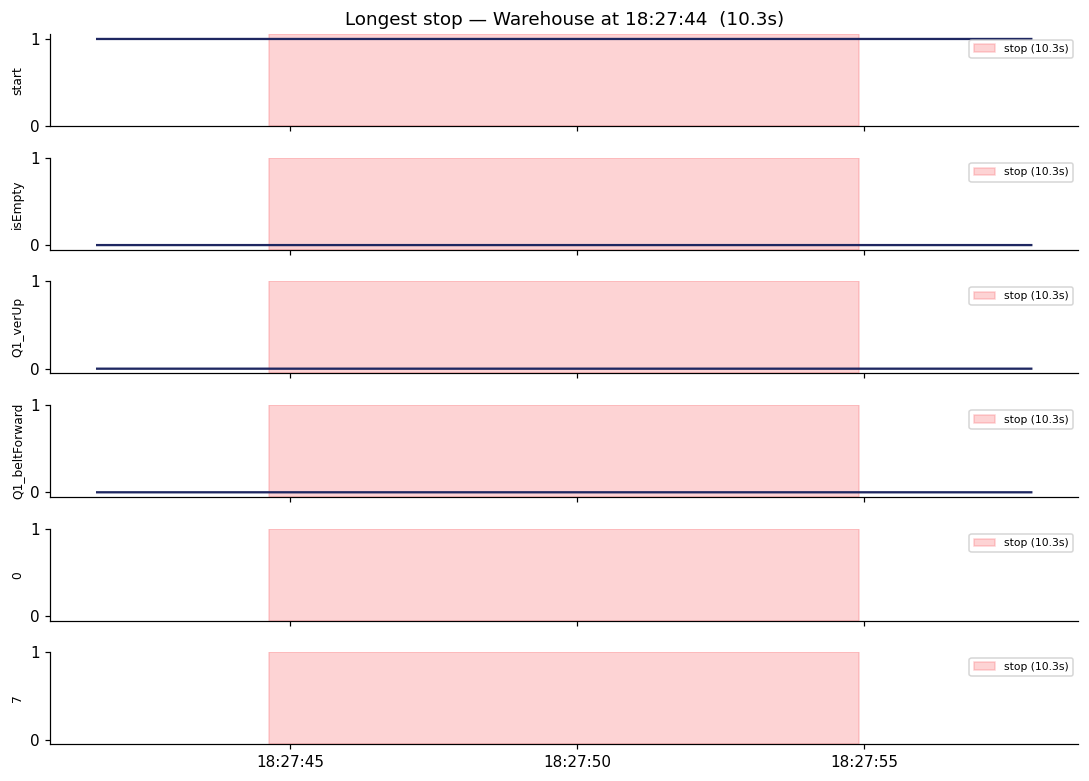

In [27]:
if not stops.empty:
    r = stops.iloc[0]
    pad = pd.Timedelta(seconds=3)
    win = merged.loc[r["start"]-pad : r["end"]+pad]
    plot_cols = [c for c in ["BEC.Visual.start", "BEC.WH.isEmpty",
                             "BEC.VG.Q1_verUp", "BEC.WH.Q1_beltForward",
                             "SIE.A0.0", "SIE.A0.7"] if c in win.columns]
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 1.2*len(plot_cols)),
                             sharex=True)
    for a, col in zip(axes, plot_cols):
        y = win[col].astype("boolean").astype(float)
        a.step(y.index, y.values, where="post", color="#1E2761")
        a.axvspan(r["start"], r["end"], color="#F96167", alpha=0.28,
                  label=f"stop ({r['duration_s']:.1f}s)")
        a.set_ylabel(col.split(".")[-1], fontsize=8)
        a.set_yticks([0,1]); a.legend(loc="upper right", fontsize=7)
    axes[0].set_title(f"Longest stop — {r['attributed_station']} at "
                      f"{r['start'].strftime('%H:%M:%S')}  ({r['duration_s']:.1f}s)")
    plt.tight_layout(); plt.show()


## 6. &nbsp; Deployment / Hand-over &nbsp; 

In a real factory the table below is what we would push to an operator
dashboard (or a Slack bot). The **attributed station** column tells the
technician exactly which cabinet to inspect first.


In [28]:
# The final engineer-facing hand-over table
engineer_view = stops.assign(
    when=lambda d: d["start"].dt.strftime("%H:%M:%S"),
    duration=lambda d: d["duration_s"].astype(str) + " s",
)[["rank", "when", "duration", "attributed_station"]]
engineer_view.columns = ["#", "when (UTC)", "duration", "suspected root cause"]
engineer_view


,#,when (UTC),duration,suspected root cause
0,1,18:27:44,10.28 s,Warehouse
1,2,18:25:30,8.76 s,Robot
2,3,18:21:14,8.48 s,Unknown
3,4,18:28:47,7.48 s,Warehouse
4,5,18:27:06,5.96 s,Robot




### Why the rule + K-Means approach is suitable for Task 1

* **Readable stop boundaries:** the 3-second silence rule is retained, so each stop's start time, end time, and duration remain easy to audit in engineering terms.
* **Machine learning support:** K-Means provides a data-driven way to separate recurring operating patterns in the factory data. The idle cluster is identified programmatically and used as an anomaly signal.
* **Cross-checking:** the K-Means idle cluster recovers a high fraction of the ticks that the rule labels as stop behaviour, even without being given stop labels during training. This provides strong supporting evidence that both methods are capturing the same low-activity periods.
* **Reusability:** the same 21-feature matrix can also support later tasks, reducing the need for additional preprocessing work.

---

### References

* Lloyd, S. P. (1982). *Least squares quantization in PCM.* IEEE
  Transactions on Information Theory, 28(2), 129–137.
* MacQueen, J. (1967). *Some methods for classification and analysis
  of multivariate observations.* Proc. 5th Berkeley Symposium on
  Mathematical Statistics and Probability.
* Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.*
  JMLR.
* Aggarwal, C. C. (2017). *Outlier Analysis* (2nd ed.). Springer.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
  Statistical Learning* (2nd ed.). Springer.
* Shannon, C. E. (1949). *Communication in the Presence of Noise.*
  Proceedings of the IRE, 37(1), 10–21.
* Shirose, K. (1992). *TPM for Workshop Leaders.* Productivity Press.
* Westkämper, E. (2006). *Einführung in die Organisation der Produktion.*
  Springer.
* Müller, F. G. (2026). *Applied Industrial AI for Manufacturing —
  Mini-Project 1 brief.* Hochschule Albstadt-Sigmaringen / plus10 GmbH.
